# Day 11 - CPV / UBL 因子（日频本地回测）

- 使用 BacktestEngine + Strategy 框架
- CPV 逻辑封装在 `CPVStrategy`
- 日频调仓，收益使用 T+1 的 `1vwap_pct`


In [1]:
# 基础依赖与配置
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from backtest_engine_strategy import BacktestEngine
from cpv_strategy import CPVStrategy

ENGINE_CFG = dict(
    data_dir='./data',
    initial_capital=1_000_000,
    commission_rate=0.0003,
    slippage_rate=0.001,
    stamp_duty=0.001,
    risk_free_rate=0.03,
)

STRATEGY_CFG = dict(
    data_dir='./data',
    candle_window_short=5,
    candle_window_long=20,
    wr_window_short=5,
    wr_window_long=20,
    min_avg_volume=5e5,
    liquidity_window=20,
    min_stock_count=200,
    min_listed_days=252,
    min_listed_coverage=0.8,
    outlier_method='sigma',
    outlier_param=3.0,
    neutralize_industry=True,
    use_long_candle=True,
    weights={'U': 1, 'B': 1, 'L': 1, 'WR': 1, 'TREND': 1},
)

BACKTEST_CFG = dict(
    start_date='2020-01-02',
    end_date='2022-01-21',
    top_n=50,
    rebalance_freq='month_start',
    enable_cost=True,
    calculate_ic=True,
    n_groups=5,
)


In [2]:
# 运行日频回测
engine = BacktestEngine(**ENGINE_CFG)
strategy = CPVStrategy(**STRATEGY_CFG)

report = engine.run(
    start_date=BACKTEST_CFG['start_date'],
    end_date=BACKTEST_CFG['end_date'],
    strategy=strategy,
    top_n=BACKTEST_CFG['top_n'],
    rebalance_freq=BACKTEST_CFG['rebalance_freq'],
    enable_cost=BACKTEST_CFG['enable_cost'],
    calculate_ic=BACKTEST_CFG['calculate_ic'],
    n_groups=BACKTEST_CFG['n_groups'],
)

engine.print_report(report)


🚀 初始化回测引擎
✅ 数据加载器初始化成功
📅 交易日数量: 500
✅ 组合管理器初始化成功
💰 初始资金: 1,000,000 元
📊 佣金费率: 3.0 万分之
📊 滑点费率: 0.10%
✅ 绩效评估器初始化成功
✅ 回测引擎初始化完成

🚀 开始回测
📅 回测区间: 2020-01-02 至 2022-01-21
📊 策略: CPV_UBL
📊 选股数量: 50
📊 调仓频率: 每 month_start 天
📊 交易成本: 启用

✅ 回测交易日数量: 500
...
✅ 回测完成,共 500 个交易日

📊 完整绩效报告
总收益率:           -19.98%
年化收益率:          -9.90%
年化波动率:          16.28%
夏普比率:            -0.79
最大回撤:            30.34%
卡玛比率:            -0.33
胜率:                47.40%

------------------------------------------------------------
📊 IC 分析
------------------------------------------------------------
IC 均值:            0.1073
IC 标准差:          0.0720
IR:                 1.4900
IC 胜率:             92.29%

------------------------------------------------------------
📊 交易统计
------------------------------------------------------------
总交易成本:          66631 元
交易次数:             2134
平均换手率:          94.96%

------------------------------------------------------------
📊 分组多空 (Group Long-Short)
-----------------------------------------

In [3]:
# 关键指标概览
key_metrics = [
    'total_return', 'annual_return', 'annual_volatility',
    'max_drawdown', 'sharpe_ratio', 'calmar_ratio', 'win_rate',
    'ic_mean', 'ic_std', 'ir', 'ic_win_rate'
]
summary = {k: report.get(k) for k in key_metrics if k in report}
pd.Series(summary)


total_return        -0.199792
annual_return       -0.099040
annual_volatility    0.162775
max_drawdown         0.303381
sharpe_ratio        -0.792756
calmar_ratio        -0.326456
win_rate             0.474000
ic_mean              0.107259
ic_std               0.071984
ir                   1.490039
ic_win_rate          0.922917
dtype: float64

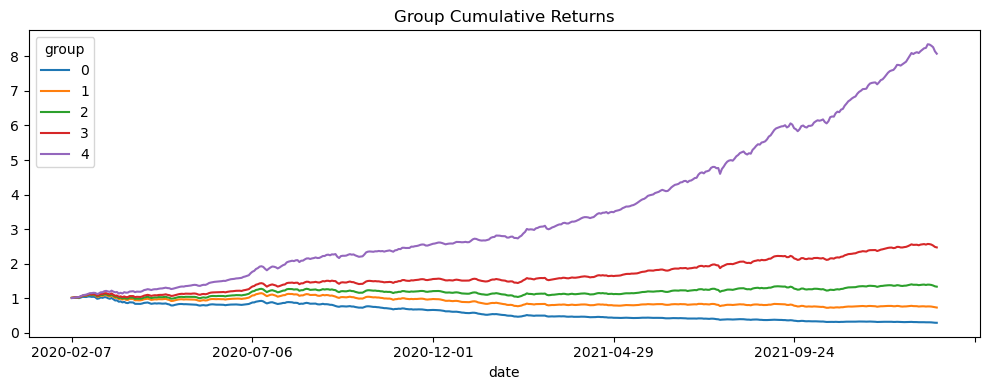

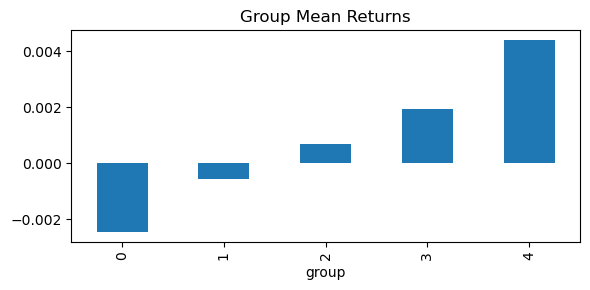

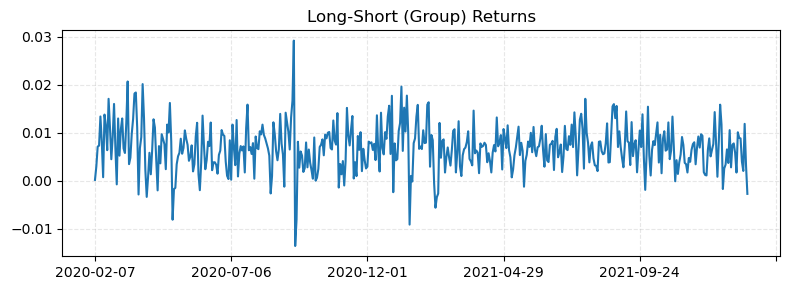

In [4]:
# 分组回测结果
group_df = report.get('group_returns')
ls_series = report.get('group_ls_returns')
if group_df is None or group_df.empty:
    print('group_returns is empty')
else:
    group_df = group_df.sort_values('date')
    pivot = group_df.pivot(index='date', columns='group', values='ret')
    cum = (1 + pivot).cumprod()
    plt.figure(figsize=(10, 4))
    cum.plot(ax=plt.gca(), title='Group Cumulative Returns')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    pivot.mean().plot(kind='bar', title='Group Mean Returns')
    plt.tight_layout()
    plt.show()

if ls_series is not None and not ls_series.empty:
    plt.figure(figsize=(8, 3))
    ls_series.sort_index().plot(title='Long-Short (Group) Returns')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


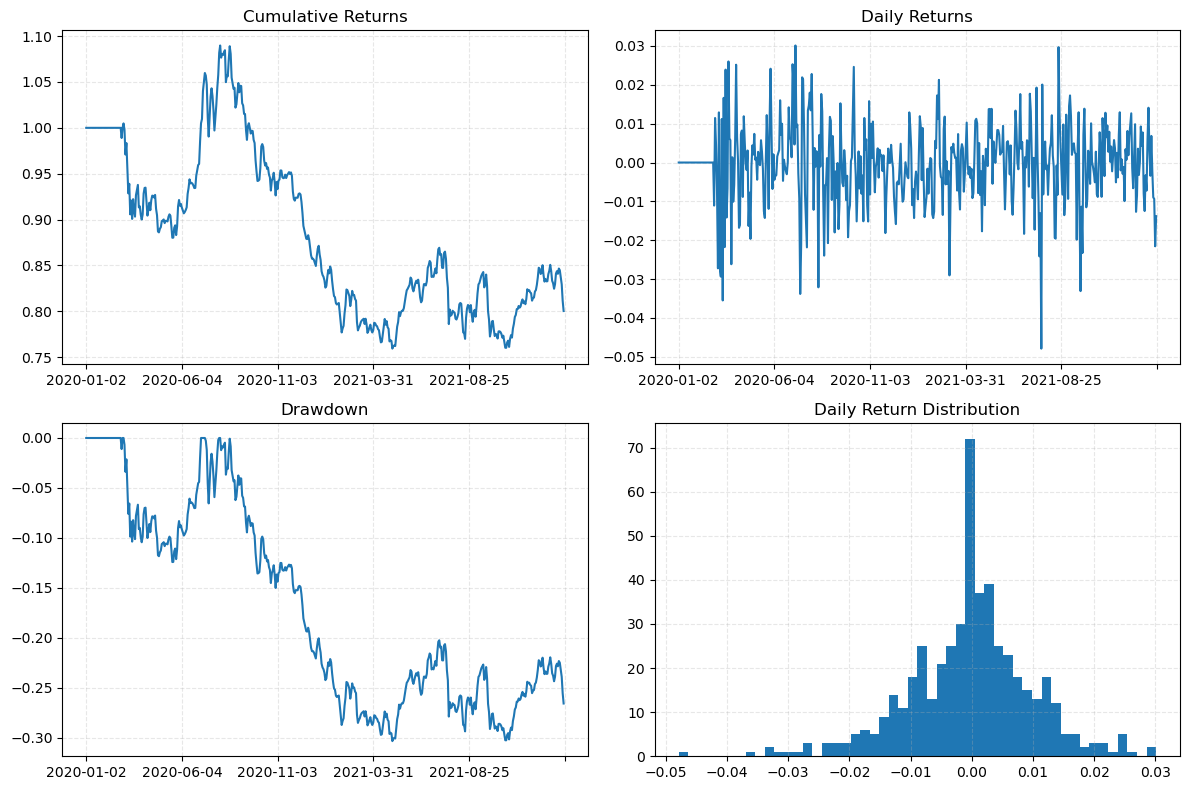

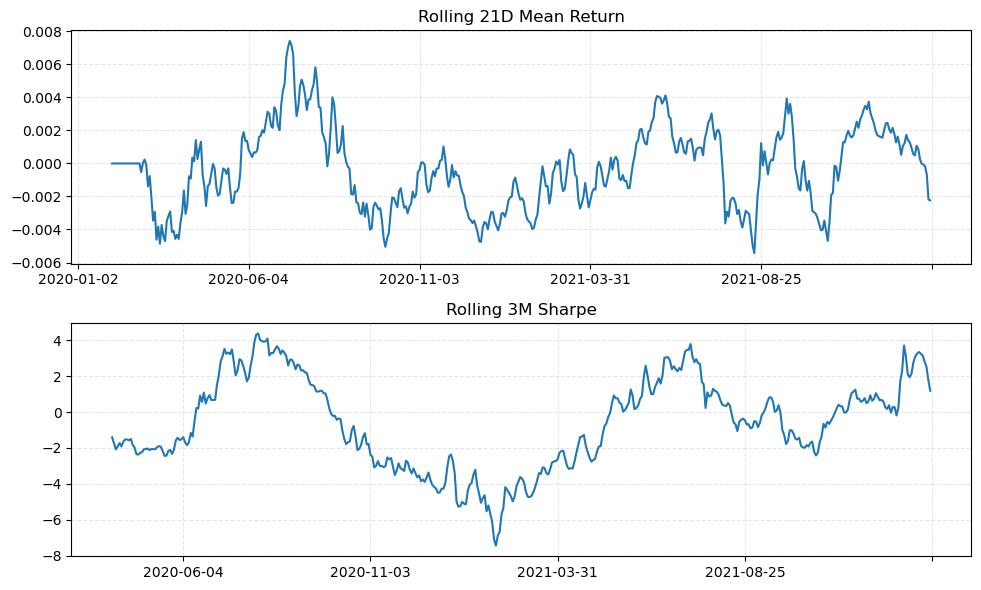

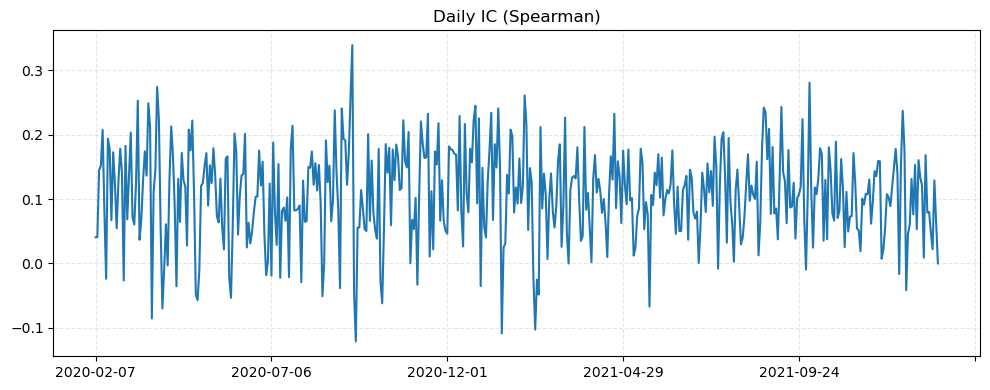

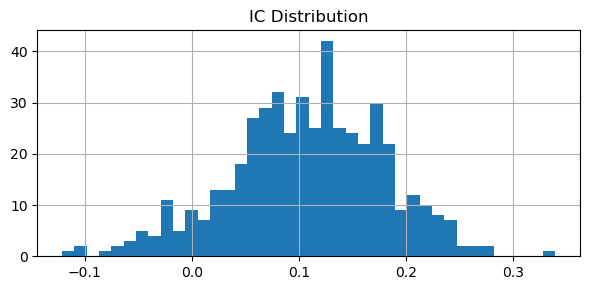

In [5]:
# 可视化：净值 / 日收益 / IC 序列
cum = report['cumulative_returns']
daily = report['daily_returns']
ic_series = report.get('ic_series')

drawdown = cum / cum.cummax() - 1
rolling_ret = daily.rolling(21).mean()
rolling_vol = daily.rolling(63).std()
rolling_sharpe = (daily.rolling(63).mean() / (rolling_vol + 1e-8)) * (252 ** 0.5)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
cum.plot(ax=ax[0, 0], title='Cumulative Returns')
daily.plot(ax=ax[0, 1], title='Daily Returns')
drawdown.plot(ax=ax[1, 0], title='Drawdown')
daily.hist(ax=ax[1, 1], bins=50)
ax[1, 1].set_title('Daily Return Distribution')
for axis in ax.ravel():
    axis.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
rolling_ret.plot(ax=ax[0], title='Rolling 21D Mean Return')
rolling_sharpe.plot(ax=ax[1], title='Rolling 3M Sharpe')
for axis in ax:
    axis.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

if ic_series is not None and not ic_series.empty:
    plt.figure(figsize=(10, 4))
    ic_series.plot(title='Daily IC (Spearman)')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    ic_series.hist(bins=40)
    plt.title('IC Distribution')
    plt.tight_layout()
    plt.show()
